# Importing libraries

In [ ]:
!pip install gradio
!pip install --upgrade gradio
!pip install gradio transformers
!pip install datasets
!pip install lime
!pip install prophet
!pip install tensorflow
!pip install prophet
!pip install gradio transformers openai langchain matplotlib plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torc

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random
import openai
import lime.lime_tabular
import lightgbm as lgb
import dask
import re
import string
import tensorflow as tf
import plotly.express as px
import dask.dataframe as dd
from prophet import Prophet
from joblib import Memory
import tensorflow.lite as tflite
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from functools import lru_cache
from scipy.optimize import linprog
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from transformers import pipeline
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from transformers import T5Tokenizer, T5ForConditionalGeneration
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Model

In [ ]:
# function for Anomaly Detection in Operational Processes
def anomaly_detection(file, contamination, nu, eps, min_samples, algorithm):
    df = pd.read_csv(file.name)

    # Encode categorical columns
    label_columns = ['gender', 'Investment_Avenues', 'Objective', 'Purpose', 'Invest_Monitor', 'Avenue',
                     'What are your savings objectives?', 'Reason_Equity', 'Reason_Mutual',
                     'Reason_Bonds', 'Reason_FD', 'Source']
    label_encoder = LabelEncoder()
    for column in label_columns:
        if column in df.columns:
            df[column] = label_encoder.fit_transform(df[column].astype(str))

    # Handle missing values
    numeric_columns = df.select_dtypes(include=np.number).columns
    df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

    # Feature Scaling
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df[numeric_columns])

    # Assign true labels for anomalies (simulated for evaluation)
    df['True_Label'] = np.random.choice([0, 1], size=len(df), p=[0.95, 0.05])
    true_labels = df['True_Label']

    # Select and train anomaly detection model
    if algorithm == 'Isolation Forest':
        model = IsolationForest(n_estimators=100, contamination=contamination, n_jobs=-1)
        df['anomaly'] = model.fit_predict(df_scaled)
    elif algorithm == 'One-Class SVM':
        model = OneClassSVM(nu=nu, kernel="rbf", gamma='scale')
        df['anomaly'] = model.fit_predict(df_scaled)
    elif algorithm == 'DBSCAN':
        model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        df['anomaly'] = model.fit_predict(df_scaled)

    # Convert anomaly labels to binary (1 for anomaly, 0 for normal)
    df['anomaly'] = np.where(df['anomaly'] == -1, 1, 0)

    # Evaluation Metrics
    precision = precision_score(true_labels, df['anomaly'], average='binary', zero_division=1)
    recall = recall_score(true_labels, df['anomaly'], average='binary')
    f1 = f1_score(true_labels, df['anomaly'], average='binary')
    metrics = f"Precision: {precision:.2f}\nRecall: {recall:.2f}\nF1-Score: {f1:.2f}"

    # Visualization of anomalies
    fig, ax = plt.subplots(figsize=(10, 5))
    if 'age' in df.columns and 'Mutual_Funds' in df.columns:
        sns.scatterplot(x=df['age'], y=df['Mutual_Funds'], hue=df['anomaly'], palette='coolwarm', s=50, ax=ax)
        ax.set_title(f'{algorithm} Anomaly Detection')
    else:
        ax.text(0.5, 0.5, "Insufficient data for visualization", horizontalalignment='center', verticalalignment='center', fontsize=12)

    return fig, metrics

#Function of chatbot
# Question Bank
question_bank = {
    "Fraud Detection Support": {
        "what is fraud detection?": "fraud detection involves monitoring transactions in real-time to identify suspicious activities.",
        "how can i report fraud?": "you can report fraud via the support center or call our helpline.",
        "what are the common fraud indicators?": "common indicators include unusual transaction locations, rapid money movement, and large cash withdrawals.",
        "how does ai help in fraud detection?": "ai uses machine learning to analyze transaction patterns and flag anomalies.",
        "can i track my fraud report?": "yes, you can track it via the fraud report dashboard.",
        "what security measures can i take?": "use strong passwords, enable 2fa, and monitor your statements regularly.",
        "what happens after reporting fraud?": "our investigation team will review and take appropriate actions.",
        "are all flagged transactions fraudulent?": "no, some may be false positives; manual review is recommended.",
        "how long does fraud investigation take?": "it varies based on the complexity, but typically 3-7 business days.",
        "can ai prevent fraud?": "ai can detect and reduce fraud by identifying suspicious patterns early.",
        "how do banks detect fraud?": "banks use a combination of rule-based systems and ai models to detect fraud.",
        "what is real-time fraud detection?": "it is the process of identifying and preventing fraud as transactions occur.",
        "what are some real-life fraud cases?": "credit card fraud, insurance fraud, and identity theft are common cases.",
        "how does biometric authentication help in fraud detection?": "it adds an extra layer of security by using unique identifiers like fingerprints or facial recognition.",
        "what is transaction monitoring?": "it is the process of analyzing transactions for suspicious activities.",
        "what is the role of blockchain in fraud prevention?": "blockchain enhances transparency and security, making fraud harder to execute.",
        "how do fraudsters bypass security measures?": "they use phishing, social engineering, and malware to bypass security.",
        "what industries are most affected by fraud?": "finance, e-commerce, healthcare, and insurance are highly targeted.",
        "what is multi-factor authentication (mfa)?": "mfa requires multiple forms of verification to enhance security.",
        "how can i secure my online transactions?": "use encrypted payment gateways, strong passwords, and monitor transactions regularly."
    },
    "Predictive Analytics": {
        "what is sales forecasting?": "sales forecasting predicts future sales based on historical data and trends.",
        "how is sales prediction done?": "using statistical models like arima, lstm, and regression analysis.",
        "why is predictive analytics important?": "it helps businesses plan resources, inventory, and marketing efforts.",
        "what data is required for sales forecasting?": "historical sales data, market trends, and external factors like seasonality.",
        "can ai improve forecasting accuracy?": "yes, ai models analyze complex patterns and improve accuracy.",
        "what is trend analysis?": "trend analysis identifies patterns in historical data to predict future changes.",
        "how do i visualize sales trends?": "we use graphs like time-series plots and moving averages.",
        "can i forecast revenue?": "yes, predictive models can estimate future revenue based on historical data.",
        "what industries benefit from predictive analytics?": "retail, finance, healthcare, and supply chain industries use it extensively.",
        "what tools are used for predictive analytics?": "python libraries like pandas, scikit-learn, and tensorflow are commonly used.",
        "what is demand forecasting?": "demand forecasting predicts future customer demand based on data trends.",
        "what is time-series analysis?": "time-series analysis examines patterns over time to make future predictions.",
        "how does seasonality affect sales forecasting?": "seasonal changes impact demand, requiring adjustments in forecasts.",
        "what is regression analysis?": "it is a statistical method to understand relationships between variables.",
        "how does machine learning improve forecasting?": "ml algorithms identify hidden patterns that traditional methods might miss.",
        "what are key challenges in predictive analytics?": "data quality, model selection, and dynamic market conditions are key challenges.",
        "what is overfitting in predictive models?": "overfitting occurs when a model learns noise instead of actual patterns.",
        "how can businesses use predictive analytics?": "they use it for demand planning, inventory optimization, and risk assessment.",
        "what are common predictive analytics models?": "decision trees, neural networks, and ensemble models are widely used.",
        "how does ai handle big data for forecasting?": "ai processes large datasets efficiently to find meaningful insights."
    },
    "Document & Email Classification": {
        "what is document classification?": "document classification is the process of categorizing documents into predefined classes based on their content.",
        "what is email classification?": "email classification involves sorting incoming emails into categories like spam, work, personal, etc.",
        "how can ai help in document classification?": "ai models use text classification algorithms to automatically categorize documents based on keywords, phrases, and context.",
        "what types of documents can be classified?": "invoices, contracts, resumes, and customer feedback forms are examples of documents that can be classified.",
        "what is the role of machine learning in email classification?": "machine learning models can be trained to identify and filter spam or categorize emails based on content and context.",
        "how accurate is document classification with ai?": "ai-based classification can achieve high accuracy, but results may vary depending on the quality of the data and model training.",
        "what tools are used for document classification?": "tools like tensorflow, scikit-learn, and spacy are commonly used for text classification tasks.",
        "what is natural language processing (nlp)?": "nlp allows machines to understand and process human language.",
        "how does spam filtering work?": "spam filters analyze email content and metadata to detect and filter unwanted emails.",
        "what is text mining?": "text mining involves extracting useful information from large amounts of text data.",
        "what are common challenges in document classification?": "data ambiguity, domain-specific terms, and language variations pose challenges.",
        "how do ai models learn to classify documents?": "they use supervised learning techniques with labeled training data.",
        "what is named entity recognition (ner)?": "ner identifies and categorizes proper names in text, such as names of people or organizations.",
        "how does ai detect phishing emails?": "it analyzes email content, sender details, and embedded links for suspicious patterns.",
        "how can ai improve email security?": "ai helps in detecting spam, phishing, and malware attacks in email communications.",
        "what is tokenization in nlp?": "tokenization breaks text into smaller parts, like words or sentences, for analysis.",
        "how does ai handle multilingual document classification?": "models trained on multiple languages can classify multilingual content.",
        "what is sentiment analysis in text classification?": "sentiment analysis determines whether a text expresses a positive, negative, or neutral sentiment."
    },
    "expense management & fraud detection": {
      "what is expense management?": "expense management is the process of tracking, controlling, and optimizing the spending of a business or individual.",
      "how does fraud detection help in expense management?": "fraud detection helps in identifying and preventing unauthorized or suspicious transactions that may inflate expenses.",
      "what are common fraud indicators in expenses?": "unusual or excessive spending patterns, unapproved transactions, or false expense claims are common fraud indicators.",
      "how can ai help in fraud detection for expenses?": "ai analyzes transaction patterns to detect outliers or unusual activities that could indicate fraudulent behavior.",
      "can ai prevent fraudulent expenses?": "ai can flag potentially fraudulent expenses, which can then be investigated manually.",
      "what are some tools for expense management?": "expense management tools include expensify, zoho expense, and quickbooks.",
      "how do businesses track expenses?": "businesses use accounting software, spreadsheets, and ai-powered tools to track expenses effectively.",
      "what role does automation play in expense management?": "automation helps in categorizing expenses, detecting anomalies, and generating financial reports.",
      "what are best practices for managing expenses?": "setting budgets, tracking receipts, and regularly auditing expenses are best practices.",
      "how do businesses prevent expense fraud?": "they implement strict policies, require receipts for reimbursements, and use ai to flag anomalies.",
      "what is expense policy compliance?": "expense policy compliance ensures employees adhere to the organization's financial policies when making purchases.",
      "how do real-time analytics help in fraud detection?": "real-time analytics detect unusual spending patterns immediately, allowing quick action against fraud.",
      "how do companies monitor employee expenses?": "companies use automated expense tracking software and periodic audits.",
      "what industries benefit most from expense management solutions?": "industries like finance, travel, healthcare, and corporate enterprises benefit significantly.",
      "what is the impact of ai on expense tracking?": "ai improves accuracy, speeds up approvals, and minimizes human errors in expense tracking.",
      "how can businesses control unnecessary expenses?": "they can implement spending limits, automate approvals, and regularly review expense reports.",
      "what are some common expense fraud schemes?": "duplicate reimbursements, overstated claims, and false receipts are common fraud schemes.",
      "how does ai differentiate between legitimate and fraudulent expenses?": "ai uses pattern recognition and anomaly detection techniques to flag unusual claims.",
      "how do financial audits detect fraud in expenses?": "audits compare expense reports with financial records to identify discrepancies.",
      "how does blockchain improve expense management security?": "blockchain provides a tamper-proof ledger of transactions, reducing fraud risks."
    },
    "anomaly detection in operations": {
      "what is anomaly detection?": "anomaly detection is the process of identifying rare items, events, or observations that deviate significantly from the general pattern in data.",
      "how does anomaly detection help in operations?": "anomaly detection helps in identifying operational issues, such as system failures, production defects, or unusual resource usage.",
      "what techniques are used for anomaly detection?": "common techniques include statistical methods, machine learning models like isolation forests, and neural networks.",
      "what are some applications of anomaly detection in operations?": "applications include detecting machine malfunctions, identifying abnormal sales trends, or monitoring system performance.",
      "can ai improve anomaly detection?": "yes, ai can enhance anomaly detection by learning complex patterns and adapting to changing conditions in real time.",
      "what industries use anomaly detection?": "industries like manufacturing, healthcare, finance, and cybersecurity use anomaly detection extensively to improve operations.",
      "what is real-time anomaly detection?": "real-time anomaly detection identifies irregularities instantly and allows for immediate corrective actions.",
      "how do businesses use anomaly detection for cybersecurity?": "businesses use it to detect unusual login activities, data breaches, and unauthorized access.",
      "how does anomaly detection prevent financial fraud?": "it flags unusual transactions, enabling early fraud prevention.",
      "what are the challenges of anomaly detection?": "challenges include high false positive rates and the need for continuous model updates.",
      "what role does deep learning play in anomaly detection?": "deep learning models detect hidden anomalies by analyzing complex data structures.",
      "how does anomaly detection improve manufacturing processes?": "it identifies defects and equipment failures, reducing downtime and production losses.",
      "what are the benefits of using ai for anomaly detection?": "ai improves accuracy, reduces manual monitoring, and adapts to evolving data patterns.",
      "how do organizations train anomaly detection models?": "they use historical data, labeled anomalies, and unsupervised learning techniques.",
      "how does anomaly detection contribute to quality control?": "it ensures product consistency by identifying defective units in production lines.",
      "how does predictive maintenance relate to anomaly detection?": "predictive maintenance uses anomaly detection to identify early signs of equipment failure.",
      "what are the different types of anomalies detected in operations?": "types include point anomalies, contextual anomalies, and collective anomalies.",
      "how do businesses reduce false positives in anomaly detection?": "they fine-tune models, incorporate domain expertise, and use hybrid approaches.",
      "how does anomaly detection impact decision-making?": "it provides data-driven insights, helping businesses take proactive actions against potential issues."
        }
    }
# Function for chatbot
def chatbot(selected_module, user_input):
    """ AI chatbot that retrieves answers from a predefined question bank. """
    # chatbot_response function moved outside chatbot function
def chatbot_response(user_input, selected_module):
        responses = question_bank.get(selected_module, {})
        return responses.get(user_input, "I can provide general insights on this topic!")

        return chatbot_response(user_input, selected_module)

# Function for spam detection
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text

def train_and_save_model(uploaded_file):
    df = pd.read_csv(uploaded_file, encoding='latin-1')
    df = df[['email', 'label']]
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})
    df['email'] = df['email'].apply(clean_text)

    X_train, X_test, y_train, y_test = train_test_split(df['email'], df['label'], test_size=0.2, random_state=42)
    vectorizer = TfidfVectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, predictions)
    report = classification_report(y_test, predictions)

    joblib.dump(model, "spam_model.pkl")
    joblib.dump(vectorizer, "vectorizer.pkl")

    return f"Model trained successfully!\nAccuracy: {acc:.2f}\n\nClassification Report:\n{report}"


#Function for Salary prediction
def train_model():
    # Load dataset
    df = pd.read_csv("/content/Salary Data.csv")  # Replace with actual dataset path

    # Handle missing values in the target variable ('Salary') before splitting
    df.dropna(subset=['Salary'], inplace=True)

    # Define features and target
    X = df[['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience']]
    y = df['Salary']

    # Preprocessing
    categorical_features = ['Gender', 'Education Level', 'Job Title']
    numeric_features = ['Age', 'Years of Experience']

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

    # Model pipeline
    model = Pipeline([
        ('preprocess', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ])

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train model
    model.fit(X_train, y_train)

    # Save model
    joblib.dump(model, "salary_model.pkl")

def predict_salary(age, gender, education_level, job_title, years_experience):
    model = joblib.load("salary_model.pkl")
    input_data = pd.DataFrame([[age, gender, education_level, job_title, years_experience]],
                              columns=['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'])
    prediction = model.predict(input_data)[0]
    return {"Predicted Annual Salary": f"${prediction:,.2f}"}

gender_options = ['Male', 'Female', 'Other']
education_options = ['High School', 'Bachelor\'s', 'Master\'s', 'PhD']
job_title_options = ['Software Engineer', 'Data Scientist', 'Product Manager', 'Analyst', 'Other']


# Function for NER model
# Load the pre-trained NER model with proper aggregation
ner_model = pipeline("ner", model="dbmdz/bert-large-cased-finetuned-conll03-english", aggregation_strategy="simple")

# Function to extract named entities from text
def extract_entities(text):
    # Get the NER predictions
    ner_results = ner_model(text)

    # Ensure entities are properly extracted
    if not ner_results:
        return [{"word": "N/A", "entity": "None", "score": 0.00}]

    # Format output properly
    formatted_entities = []
    for result in ner_results:
        word = result.get("word", "N/A")  # Ensure word is retrieved correctly
        entity = result.get("entity_group", "Unknown")  # Use 'entity_group' for better grouping
        score = round(result.get("score", 2), 2)  # Round score for better readability

        formatted_entities.append({"word": word, "entity": entity, "score": score})

    return formatted_entities

#Function for summarization
# Load the pre-trained T5 model
model_name = "t5-base"  # Change to "t5-large" for better quality
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Function to summarize text
def summarize_text(input_text, summary_length):
    if len(input_text.strip()) == 0:
        return "⚠️ Please enter some text to summarize."

    # Preprocess text
    input_text = "summarize: " + input_text
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)

    # Generate summary
    summary_ids = model.generate(inputs.input_ids, max_length=summary_length, min_length=50, length_penalty=2.0, num_beams=4)
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    return summary


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

# GUI

In [ ]:

# Integrated Gradio UI
with gr.Blocks(theme="glass") as app:
    gr.Markdown("# 🚀 Comprehensive Enterprise Insights Platform")

    with gr.Tabs():

        # Anomaly Detection
        with gr.Tab("Anomaly Detection"):
            file = gr.File(label="Upload Financial Data (CSV)")
            contamination = gr.Slider(0.01, 0.5, step=0.01, label="Contamination (Isolation Forest)")
            nu = gr.Slider(0.01, 0.5, step=0.01, label="nu (One-Class SVM)")
            eps = gr.Slider(0.1, 10, step=0.1, label="eps (DBSCAN)")
            min_samples = gr.Slider(2, 20, step=1, label="min_samples (DBSCAN)")
            algorithm = gr.Dropdown(['Isolation Forest', 'One-Class SVM', 'DBSCAN'], label='Select Algorithm')
            plot_output = gr.Plot()
            metrics_output = gr.Textbox(label="Evaluation Metrics")

            gr.Interface(
                fn=anomaly_detection,
                inputs=[file, contamination, nu, eps, min_samples, algorithm],
                outputs=[plot_output, metrics_output],
                title="  📊 Comprehensive Anomaly Detection in Financial Data 🔍",
                description="""
                Detect anomalies in financial datasets using different machine learning models:
                - **Isolation Forest** 🏞️
                - **One-Class SVM** 💡
                - **DBSCAN** 🔢

                Upload your dataset, choose an algorithm, and adjust hyperparameters dynamically. The results include:
                - Anomaly Visualization 📉
                - Precision, Recall, and F1-Score 📊
                - Interactive Analysis 🛠️
                """,
                theme="compact"
            )

        # Tab for Chatbot
        with gr.Tab("Chatbot"):
            gr.Markdown("## 💬 Ask the Chatbot")

            with gr.Column():
                gr.Markdown("<h3>💡 Select a Module & Ask Your Question</h3>")

                module_dropdown = gr.Dropdown(
                    list(question_bank.keys()), label="Select Module", interactive=True
                )

                chatbot_input = gr.Textbox(
                    label="Enter your question", placeholder="Type your question here...", lines=2
                )

                chatbot_button = gr.Button("🔍 Get Answer", variant="primary")

            with gr.Column():
                gr.Markdown("<h3>📝 Chatbot Response</h3>")
                chatbot_output = gr.Textbox(
                    label="Response", interactive=False, lines=4, elem_id="response_box"
                )

            chatbot_button.click(chatbot_response, inputs=[chatbot_input, module_dropdown], outputs=chatbot_output)


        # Tab for Spam Detection
        with gr.Tab("Spam Email Detection"):
            gr.Markdown("## 📧 Spam Email Detection")

            file_input = gr.File(label="Upload Dataset (CSV)")

            gr.Markdown("## Train Model")
            train_button = gr.Button("Train Model")
            train_output = gr.Textbox()
            train_button.click(train_and_save_model, inputs=file_input, outputs=train_output)

            gr.Markdown("## Predict Spam")
            text_input = gr.Textbox(label="Enter Email Text")
            predict_button = gr.Button("Check")
            result = gr.Textbox()
            predict_button.click(predict_spam, inputs=text_input, outputs=result)

        # Tab for Salary Prediction
        with gr.Tab("Salary Prediction"):
            gr.Markdown("""
                # 💼 Salary Prediction Model
                **Estimate salaries based on personal and job-related attributes!**
                - 📊 **Use Case**: Helps in salary benchmarking, job offer evaluation, and financial planning.
                - 📝 **Input**: Provide age, gender, education level, job title, and years of experience.
                - 💰 **Output**: Estimated salary based on trained ML model.
                """)

            age_input = gr.Number(label="Age")
            gender_input = gr.Dropdown(choices=gender_options, label="Gender")
            education_input = gr.Dropdown(choices=education_options, label="Education Level")
            job_title_input = gr.Dropdown(choices=job_title_options, label="Job Title")
            experience_input = gr.Number(label="Years of Experience")
            predict_button = gr.Button("Predict Salary")
            output_salary = gr.Textbox(label="Predicted Salary")

            predict_button.click(predict_salary, inputs=[age_input, gender_input, education_input, job_title_input, experience_input], outputs=output_salary)

        # Tab For NER
        with gr.Tab("Named Entity Recognition (NER)"):
            gr.Markdown("""
                # 📌 Named Entity Recognition (NER) with BERT
                **Extract named entities like Persons, Organizations, and Locations from text!**
                - 🔍 **Use Case**: Information extraction, document processing, and NLP-based analytics.
                - ✍️ **Input**: Enter text in the box below.
                - 📊 **Output**: Detected entities with confidence scores.
            """)

            # Text Input
            text_input = gr.Textbox(lines=7, placeholder="Enter text here for NER analysis...", label="Input Text")

            # Extract Button
            extract_button = gr.Button("Extract Named Entities")

            # Output in JSON format
            output_entities = gr.JSON(label="Extracted Named Entities")

            # Action on Button Click
            extract_button.click(extract_entities, inputs=text_input, outputs=output_entities)

        #Tab for Text summarization
        with gr.Tab(" Text Summarization"):
            gr.Markdown("""
            # 📝 AI-Powered Text Summarization
            **Summarize long documents, reports, or articles into concise key points.**
            - ✅ **Use Case**: Business reports, legal documents, customer support analysis.
            - 📜 **Input**: Echnter full-length text.
            - 📄 **Output**: A summarized version generated by AI.
            """)

            # Input Box
            input_text = gr.Textbox(lines=10, placeholder="Paste your document, article, or email here...", label="Enter Full Text")

            # Summary Length Control
            summary_length = gr.Slider(minimum=50, maximum=300, step=10, value=150, label="🔧 Summary Length")

            # Buttons
            summarize_btn = gr.Button("✨ Summarize")
            clear_btn = gr.Button("🗑️ Clear")

            # Output Box
            output_text = gr.Textbox(label="📄 AI-Generated Summary", lines=5)

            # Button Actions
            summarize_btn.click(summarize_text, inputs=[input_text, summary_length], outputs=output_text)
            clear_btn.click(lambda: "", inputs=[], outputs=[input_text, output_text])


app.launch()


/usr/local/lib/python3.11/dist-packages/gradio/blocks.py:1096: UserWarning: Cannot load compact. Caught Exception: 404 Client Error: Not Found for url: https://huggingface.co/api/spaces/compact (Request ID: Root=1-67b691b6-6dcb06d65c5b16be255b2000;fbf37422-8593-4028-a093-4b01b12e51bc)

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


NameError: name 'predict_spam' is not defined

# Sample Testing

In [ ]:
# Question Bank
question_bank = {
    "Fraud Detection Support": {
        "what is fraud detection?": "fraud detection involves monitoring transactions in real-time to identify suspicious activities.",
        "how can i report fraud?": "you can report fraud via the support center or call our helpline.",
        "what are the common fraud indicators?": "common indicators include unusual transaction locations, rapid money movement, and large cash withdrawals.",
        "how does ai help in fraud detection?": "ai uses machine learning to analyze transaction patterns and flag anomalies.",
        "can i track my fraud report?": "yes, you can track it via the fraud report dashboard.",
        "what security measures can i take?": "use strong passwords, enable 2fa, and monitor your statements regularly.",
        "what happens after reporting fraud?": "our investigation team will review and take appropriate actions.",
        "are all flagged transactions fraudulent?": "no, some may be false positives; manual review is recommended.",
        "how long does fraud investigation take?": "it varies based on the complexity, but typically 3-7 business days.",
        "can ai prevent fraud?": "ai can detect and reduce fraud by identifying suspicious patterns early.",
        "how do banks detect fraud?": "banks use a combination of rule-based systems and ai models to detect fraud.",
        "what is real-time fraud detection?": "it is the process of identifying and preventing fraud as transactions occur.",
        "what are some real-life fraud cases?": "credit card fraud, insurance fraud, and identity theft are common cases.",
        "how does biometric authentication help in fraud detection?": "it adds an extra layer of security by using unique identifiers like fingerprints or facial recognition.",
        "what is transaction monitoring?": "it is the process of analyzing transactions for suspicious activities.",
        "what is the role of blockchain in fraud prevention?": "blockchain enhances transparency and security, making fraud harder to execute.",
        "how do fraudsters bypass security measures?": "they use phishing, social engineering, and malware to bypass security.",
        "what industries are most affected by fraud?": "finance, e-commerce, healthcare, and insurance are highly targeted.",
        "what is multi-factor authentication (mfa)?": "mfa requires multiple forms of verification to enhance security.",
        "how can i secure my online transactions?": "use encrypted payment gateways, strong passwords, and monitor transactions regularly."
    },
    "Predictive Analytics": {
        "what is sales forecasting?": "sales forecasting predicts future sales based on historical data and trends.",
        "how is sales prediction done?": "using statistical models like arima, lstm, and regression analysis.",
        "why is predictive analytics important?": "it helps businesses plan resources, inventory, and marketing efforts.",
        "what data is required for sales forecasting?": "historical sales data, market trends, and external factors like seasonality.",
        "can ai improve forecasting accuracy?": "yes, ai models analyze complex patterns and improve accuracy.",
        "what is trend analysis?": "trend analysis identifies patterns in historical data to predict future changes.",
        "how do i visualize sales trends?": "we use graphs like time-series plots and moving averages.",
        "can i forecast revenue?": "yes, predictive models can estimate future revenue based on historical data.",
        "what industries benefit from predictive analytics?": "retail, finance, healthcare, and supply chain industries use it extensively.",
        "what tools are used for predictive analytics?": "python libraries like pandas, scikit-learn, and tensorflow are commonly used.",
        "what is demand forecasting?": "demand forecasting predicts future customer demand based on data trends.",
        "what is time-series analysis?": "time-series analysis examines patterns over time to make future predictions.",
        "how does seasonality affect sales forecasting?": "seasonal changes impact demand, requiring adjustments in forecasts.",
        "what is regression analysis?": "it is a statistical method to understand relationships between variables.",
        "how does machine learning improve forecasting?": "ml algorithms identify hidden patterns that traditional methods might miss.",
        "what are key challenges in predictive analytics?": "data quality, model selection, and dynamic market conditions are key challenges.",
        "what is overfitting in predictive models?": "overfitting occurs when a model learns noise instead of actual patterns.",
        "how can businesses use predictive analytics?": "they use it for demand planning, inventory optimization, and risk assessment.",
        "what are common predictive analytics models?": "decision trees, neural networks, and ensemble models are widely used.",
        "how does ai handle big data for forecasting?": "ai processes large datasets efficiently to find meaningful insights."
    },
    "Document & Email Classification": {
        "what is document classification?": "document classification is the process of categorizing documents into predefined classes based on their content.",
        "what is email classification?": "email classification involves sorting incoming emails into categories like spam, work, personal, etc.",
        "how can ai help in document classification?": "ai models use text classification algorithms to automatically categorize documents based on keywords, phrases, and context.",
        "what types of documents can be classified?": "invoices, contracts, resumes, and customer feedback forms are examples of documents that can be classified.",
        "what is the role of machine learning in email classification?": "machine learning models can be trained to identify and filter spam or categorize emails based on content and context.",
        "how accurate is document classification with ai?": "ai-based classification can achieve high accuracy, but results may vary depending on the quality of the data and model training.",
        "what tools are used for document classification?": "tools like tensorflow, scikit-learn, and spacy are commonly used for text classification tasks.",
        "what is natural language processing (nlp)?": "nlp allows machines to understand and process human language.",
        "how does spam filtering work?": "spam filters analyze email content and metadata to detect and filter unwanted emails.",
        "what is text mining?": "text mining involves extracting useful information from large amounts of text data.",
        "what are common challenges in document classification?": "data ambiguity, domain-specific terms, and language variations pose challenges.",
        "how do ai models learn to classify documents?": "they use supervised learning techniques with labeled training data.",
        "what is named entity recognition (ner)?": "ner identifies and categorizes proper names in text, such as names of people or organizations.",
        "how does ai detect phishing emails?": "it analyzes email content, sender details, and embedded links for suspicious patterns.",
        "how can ai improve email security?": "ai helps in detecting spam, phishing, and malware attacks in email communications.",
        "what is tokenization in nlp?": "tokenization breaks text into smaller parts, like words or sentences, for analysis.",
        "how does ai handle multilingual document classification?": "models trained on multiple languages can classify multilingual content.",
        "what is sentiment analysis in text classification?": "sentiment analysis determines whether a text expresses a positive, negative, or neutral sentiment."
    },
    "expense management & fraud detection": {
      "what is expense management?": "expense management is the process of tracking, controlling, and optimizing the spending of a business or individual.",
      "how does fraud detection help in expense management?": "fraud detection helps in identifying and preventing unauthorized or suspicious transactions that may inflate expenses.",
      "what are common fraud indicators in expenses?": "unusual or excessive spending patterns, unapproved transactions, or false expense claims are common fraud indicators.",
      "how can ai help in fraud detection for expenses?": "ai analyzes transaction patterns to detect outliers or unusual activities that could indicate fraudulent behavior.",
        "can ai prevent fraudulent expenses?": "ai can flag potentially fraudulent expenses, which can then be investigated manually.",
      "what are some tools for expense management?": "expense management tools include expensify, zoho expense, and quickbooks.",
      "how do businesses track expenses?": "businesses use accounting software, spreadsheets, and ai-powered tools to track expenses effectively.",
      "what role does automation play in expense management?": "automation helps in categorizing expenses, detecting anomalies, and generating financial reports.",
      "what are best practices for managing expenses?": "setting budgets, tracking receipts, and regularly auditing expenses are best practices.",
      "how do businesses prevent expense fraud?": "they implement strict policies, require receipts for reimbursements, and use ai to flag anomalies.",
      "what is expense policy compliance?": "expense policy compliance ensures employees adhere to the organization's financial policies when making purchases.",
      "how do real-time analytics help in fraud detection?": "real-time analytics detect unusual spending patterns immediately, allowing quick action against fraud.",
      "how do companies monitor employee expenses?": "companies use automated expense tracking software and periodic audits.",
      "what industries benefit most from expense management solutions?": "industries like finance, travel, healthcare, and corporate enterprises benefit significantly.",
      "what is the impact of ai on expense tracking?": "ai improves accuracy, speeds up approvals, and minimizes human errors in expense tracking.",
      "how can businesses control unnecessary expenses?": "they can implement spending limits, automate approvals, and regularly review expense reports.",
      "what are some common expense fraud schemes?": "duplicate reimbursements, overstated claims, and false receipts are common fraud schemes.",
      "how does ai differentiate between legitimate and fraudulent expenses?": "ai uses pattern recognition and anomaly detection techniques to flag unusual claims.",
      "how do financial audits detect fraud in expenses?": "audits compare expense reports with financial records to identify discrepancies.",
      "how does blockchain improve expense management security?": "blockchain provides a tamper-proof ledger of transactions, reducing fraud risks."
    },
    "anomaly detection in operations": {
      "what is anomaly detection?": "anomaly detection is the process of identifying rare items, events, or observations that deviate significantly from the general pattern in data.",
      "how does anomaly detection help in operations?": "anomaly detection helps in identifying operational issues, such as system failures, production defects, or unusual resource usage.",
      "what techniques are used for anomaly detection?": "common techniques include statistical methods, machine learning models like isolation forests, and neural networks.",
      "what are some applications of anomaly detection in operations?": "applications include detecting machine malfunctions, identifying abnormal sales trends, or monitoring system performance.",
      "can ai improve anomaly detection?": "yes, ai can enhance anomaly detection by learning complex patterns and adapting to changing conditions in real time.",
      "what industries use anomaly detection?": "industries like manufacturing, healthcare, finance, and cybersecurity use anomaly detection extensively to improve operations.",
      "what is real-time anomaly detection?": "real-time anomaly detection identifies irregularities instantly and allows for immediate corrective actions.",
      "how do businesses use anomaly detection for cybersecurity?": "businesses use it to detect unusual login activities, data breaches, and unauthorized access.",
      "how does anomaly detection prevent financial fraud?": "it flags unusual transactions, enabling early fraud prevention.",
      "what are the challenges of anomaly detection?": "challenges include high false positive rates and the need for continuous model updates.",
      "what role does deep learning play in anomaly detection?": "deep learning models detect hidden anomalies by analyzing complex data structures.",
      "how does anomaly detection improve manufacturing processes?": "it identifies defects and equipment failures, reducing downtime and production losses.",
      "what are the benefits of using ai for anomaly detection?": "ai improves accuracy, reduces manual monitoring, and adapts to evolving data patterns.",
      "how do organizations train anomaly detection models?": "they use historical data, labeled anomalies, and unsupervised learning techniques.",
      "how does anomaly detection contribute to quality control?": "it ensures product consistency by identifying defective units in production lines.",
      "how does predictive maintenance relate to anomaly detection?": "predictive maintenance uses anomaly detection to identify early signs of equipment failure.",
      "what are the different types of anomalies detected in operations?": "types include point anomalies, contextual anomalies, and collective anomalies.",
      "how do businesses reduce false positives in anomaly detection?": "they fine-tune models, incorporate domain expertise, and use hybrid approaches.",
      "how does anomaly detection impact decision-making?": "it provides data-driven insights, helping businesses take proactive actions against potential issues."
        }
    }

In [ ]:
# function for Anomaly Detection in Operational Processes
def anomaly_detection(file, contamination, nu, eps, min_samples, algorithm):
    df = pd.read_csv(file.name)

    # Encode categorical columns
    label_columns = ['gender', 'Investment_Avenues', 'Objective', 'Purpose', 'Invest_Monitor', 'Avenue',
                     'What are your savings objectives?', 'Reason_Equity', 'Reason_Mutual',
                     'Reason_Bonds', 'Reason_FD', 'Source']
    label_encoder = LabelEncoder()
    for column in label_columns:
        if column in df.columns:
            df[column] = label_encoder.fit_transform(df[column].astype(str))

    # Handle missing values
    numeric_columns = df.select_dtypes(include=np.number).columns
    df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

    # Feature Scaling
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df[numeric_columns])

    # Assign true labels for anomalies (simulated for evaluation)
    df['True_Label'] = np.random.choice([0, 1], size=len(df), p=[0.95, 0.05])
    true_labels = df['True_Label']

    # Select and train anomaly detection model
    if algorithm == 'Isolation Forest':
        model = IsolationForest(n_estimators=100, contamination=contamination, n_jobs=-1)
        df['anomaly'] = model.fit_predict(df_scaled)
    elif algorithm == 'One-Class SVM':
        model = OneClassSVM(nu=nu, kernel="rbf", gamma='scale')
        df['anomaly'] = model.fit_predict(df_scaled)
    elif algorithm == 'DBSCAN':
        model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        df['anomaly'] = model.fit_predict(df_scaled)

    # Convert anomaly labels to binary (1 for anomaly, 0 for normal)
    df['anomaly'] = np.where(df['anomaly'] == -1, 1, 0)

    # Evaluation Metrics
    precision = precision_score(true_labels, df['anomaly'], average='binary', zero_division=1)
    recall = recall_score(true_labels, df['anomaly'], average='binary')
    f1 = f1_score(true_labels, df['anomaly'], average='binary')
    metrics = f"Precision: {precision:.2f}\nRecall: {recall:.2f}\nF1-Score: {f1:.2f}"

    # Visualization of anomalies
    fig, ax = plt.subplots(figsize=(10, 5))
    if 'age' in df.columns and 'Mutual_Funds' in df.columns:
        sns.scatterplot(x=df['age'], y=df['Mutual_Funds'], hue=df['anomaly'], palette='coolwarm', s=50, ax=ax)
        ax.set_title(f'{algorithm} Anomaly Detection')
    else:
        ax.text(0.5, 0.5, "Insufficient data for visualization", horizontalalignment='center', verticalalignment='center', fontsize=12)

    return fig, metrics

# Function for chatbot
def chatbot(selected_module, user_input):
    """ AI chatbot that retrieves answers from a predefined question bank. """
    # chatbot_response function moved outside chatbot function
def chatbot_response(user_input, selected_module):
        responses = question_bank.get(selected_module, {})
        return responses.get(user_input, "I can provide general insights on this topic!")

        return chatbot_response(user_input, selected_module)

# Function for spam detection
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text

def train_and_save_model(uploaded_file):
    df = pd.read_csv(uploaded_file, encoding='latin-1')
    df = df[['email', 'label']]
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})
    df['email'] = df['email'].apply(clean_text)

    X_train, X_test, y_train, y_test = train_test_split(df['email'], df['label'], test_size=0.2, random_state=42)
    vectorizer = TfidfVectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, predictions)
    report = classification_report(y_test, predictions)

    joblib.dump(model, "spam_model.pkl")
    joblib.dump(vectorizer, "vectorizer.pkl")

    return f"Model trained successfully!\nAccuracy: {acc:.2f}\n\nClassification Report:\n{report}"

def predict_spam(message):
    model = joblib.load("spam_model.pkl")
    vectorizer = joblib.load("vectorizer.pkl")
    message_tfidf = vectorizer.transform([clean_text(message)])
    prediction = model.predict(message_tfidf)[0]
    return "Spam" if prediction == 1 else "Not Spam"

#Function for Salary prediction
def train_model():
    # Load dataset
    df = pd.read_csv("/content/Salary Data.csv")  # Replace with actual dataset path

    # Handle missing values in the target variable ('Salary') before splitting
    df.dropna(subset=['Salary'], inplace=True)

    # Define features and target
    X = df[['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience']]
    y = df['Salary']

    # Preprocessing
    categorical_features = ['Gender', 'Education Level', 'Job Title']
    numeric_features = ['Age', 'Years of Experience']

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

    # Model pipeline
    model = Pipeline([
        ('preprocess', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ])

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train model
    model.fit(X_train, y_train)

    # Save model
    joblib.dump(model, "salary_model.pkl")

def predict_salary(age, gender, education_level, job_title, years_experience):
    model = joblib.load("salary_model.pkl")
    input_data = pd.DataFrame([[age, gender, education_level, job_title, years_experience]],
                              columns=['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience'])
    prediction = model.predict(input_data)[0]
    return {"Predicted Annual Salary": f"${prediction:,.2f}"}

gender_options = ['Male', 'Female', 'Other']
education_options = ['High School', 'Bachelor\'s', 'Master\'s', 'PhD']
job_title_options = ['Software Engineer', 'Data Scientist', 'Product Manager', 'Analyst', 'Other']


# Function for NER model
# Load the pre-trained NER model with proper aggregation
ner_model = pipeline("ner", model="dbmdz/bert-large-cased-finetuned-conll03-english", aggregation_strategy="simple")

# Function to extract named entities from text
def extract_entities(text):
    # Get the NER predictions
    ner_results = ner_model(text)

    # Ensure entities are properly extracted
    if not ner_results:
        return [{"word": "N/A", "entity": "None", "score": 0.00}]

    # Format output properly
    formatted_entities = []
    for result in ner_results:
        word = result.get("word", "N/A")  # Ensure word is retrieved correctly
        entity = result.get("entity_group", "Unknown")  # Use 'entity_group' for better grouping
        score = round(result.get("score", 2), 2)  # Round score for better readability

        formatted_entities.append({"word": word, "entity": entity, "score": score})

    return formatted_entities

#Function for summarization
# Load the pre-trained T5 model
model_name = "t5-base"  # Change to "t5-large" for better quality
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Function to summarize text
def summarize_text(input_text, summary_length):
    if len(input_text.strip()) == 0:
        return "⚠️ Please enter some text to summarize."

    # Preprocess text
    input_text = "summarize: " + input_text
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)

    # Generate summary
    summary_ids = model.generate(inputs.input_ids, max_length=summary_length, min_length=50, length_penalty=2.0, num_beams=4)
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    return summary

#Function for fraud detection
# Function to process dataset and train model
def train_and_predict(data):
    df = data.copy()

    # Data Preprocessing
    X = df.drop(columns=["Class"])
    y = df["Class"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predictions & Evaluation
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    cm = confusion_matrix(y_test, y_pred)

    return report, auc, cm

# Function for EDA visualizations
def generate_plots(data):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Fraud vs Non-Fraud Distribution
    sns.countplot(x="Class", data=data, ax=axes[0, 0])
    axes[0, 0].set_title("Fraud vs Non-Fraud Distribution")

    # Amount Distribution
    sns.histplot(data["Amount"], bins=50, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title("Transaction Amount Distribution")

    # Time Distribution
    sns.histplot(data["Time"], bins=50, kde=True, ax=axes[0, 2])
    axes[0, 2].set_title("Transaction Time Distribution")

    # Correlation Heatmap
    sns.heatmap(data.corr(), cmap="coolwarm", ax=axes[1, 0])
    axes[1, 0].set_title("Correlation Heatmap")

    # Boxplot for Amount
    sns.boxplot(x=data["Amount"], ax=axes[1, 1])
    axes[1, 1].set_title("Boxplot of Transaction Amount")

    plt.tight_layout()
    return fig

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [ ]:

# Integrated Gradio UI
with gr.Blocks(theme="glass") as app:
    gr.Markdown("# 🚀 Comprehensive Enterprise Insights Platform")

    with gr.Tabs():

        # Anomaly Detection
        with gr.Tab("Anomaly Detection"):
            file = gr.File(label="Upload Financial Data (CSV)")
            contamination = gr.Slider(0.01, 0.5, step=0.01, label="Contamination (Isolation Forest)")
            nu = gr.Slider(0.01, 0.5, step=0.01, label="nu (One-Class SVM)")
            eps = gr.Slider(0.1, 10, step=0.1, label="eps (DBSCAN)")
            min_samples = gr.Slider(2, 20, step=1, label="min_samples (DBSCAN)")
            algorithm = gr.Dropdown(['Isolation Forest', 'One-Class SVM', 'DBSCAN'], label='Select Algorithm')
            plot_output = gr.Plot()
            metrics_output = gr.Textbox(label="Evaluation Metrics")

            gr.Interface(
                fn=anomaly_detection,
                inputs=[file, contamination, nu, eps, min_samples, algorithm],
                outputs=[plot_output, metrics_output],
                title="  📊 Comprehensive Anomaly Detection in Financial Data 🔍",
                description="""
                Detect anomalies in financial datasets using different machine learning models:
                - **Isolation Forest** 🏞️
                - **One-Class SVM** 💡
                - **DBSCAN** 🔢

                Upload your dataset, choose an algorithm, and adjust hyperparameters dynamically. The results include:
                - Anomaly Visualization 📉
                - Precision, Recall, and F1-Score 📊
                - Interactive Analysis 🛠️
                """,
                theme="compact"
            )

        # Tab for Chatbot
        with gr.Tab("Chatbot"):
            gr.Markdown("## 💬 Ask the Chatbot")

            with gr.Column():
                gr.Markdown("<h3>💡 Select a Module & Ask Your Question</h3>")

                module_dropdown = gr.Dropdown(
                    list(question_bank.keys()), label="Select Module", interactive=True
                )

                chatbot_input = gr.Textbox(
                    label="Enter your question", placeholder="Type your question here...", lines=2
                )

                chatbot_button = gr.Button("🔍 Get Answer", variant="primary")

            with gr.Column():
                gr.Markdown("<h3>📝 Chatbot Response</h3>")
                chatbot_output = gr.Textbox(
                    label="Response", interactive=False, lines=4, elem_id="response_box"
                )

            chatbot_button.click(chatbot_response, inputs=[chatbot_input, module_dropdown], outputs=chatbot_output)


        # Tab for Spam Detection
        with gr.Tab("Spam Email Detection"):
            gr.Markdown("""
            # 📧 Spam Email Detection Model
            **Detect and filter spam emails using a trained machine learning model!**

            Upload your dataset, train the model, and check email texts dynamically. The results include:
            - 📊 **Model Accuracy and Classification Report**
            - 📨 **Spam Detection for Email Texts**
            - ⚡ **Efficient and Fast Processing**""")

            file_input = gr.File(label="Upload Dataset (CSV)")

            gr.Markdown("## Train Model")
            train_button = gr.Button("Train Model")
            train_output = gr.Textbox()
            train_button.click(train_and_save_model, inputs=file_input, outputs=train_output)

            gr.Markdown("## Predict Spam")
            text_input = gr.Textbox(label="Enter Email Text")
            predict_button = gr.Button("Check")
            result = gr.Textbox()
            predict_button.click(predict_spam, inputs=text_input, outputs=result)

        # Tab for Salary Prediction
        with gr.Tab("Salary Prediction"):
            gr.Markdown("""
                # 💼 Salary Prediction Model
                **Estimate salaries based on personal and job-related attributes!**
                - 📊 **Use Case**: Helps in salary benchmarking, job offer evaluation, and financial planning.
                - 📝 **Input**: Provide age, gender, education level, job title, and years of experience.
                - 💰 **Output**: Estimated salary based on trained ML model.
                """)

            age_input = gr.Number(label="Age")
            gender_input = gr.Dropdown(choices=gender_options, label="Gender")
            education_input = gr.Dropdown(choices=education_options, label="Education Level")
            job_title_input = gr.Dropdown(choices=job_title_options, label="Job Title")
            experience_input = gr.Number(label="Years of Experience")
            predict_button = gr.Button("Predict Salary")
            output_salary = gr.JSON(label="Predicted Salary")

            predict_button.click(predict_salary, inputs=[age_input, gender_input, education_input, job_title_input, experience_input], outputs=output_salary)

        # Tab For NER
        with gr.Tab("Named Entity Recognition (NER)"):
            gr.Markdown("""
                # 📌 Named Entity Recognition (NER) with BERT
                **Extract named entities like Persons, Organizations, and Locations from text!**
                - 🔍 **Use Case**: Information extraction, document processing, and NLP-based analytics.
                - ✍️ **Input**: Enter text in the box below.
                - 📊 **Output**: Detected entities with confidence scores.
            """)

            # Text Input
            text_input = gr.Textbox(lines=7, placeholder="Enter text here for NER analysis...", label="Input Text")

            # Extract Button
            extract_button = gr.Button("Extract Named Entities")

            # Output in JSON format
            output_entities = gr.JSON(label="Extracted Named Entities")

            # Action on Button Click
            extract_button.click(extract_entities, inputs=text_input, outputs=output_entities)

        #Tab for Text summarization
        with gr.Tab(" Text Summarization"):
            gr.Markdown("""
            # 📝 AI-Powered Text Summarization
            **Summarize long documents, reports, or articles into concise key points.**
            - ✅ **Use Case**: Business reports, legal documents, customer support analysis.
            - 📜 **Input**: Echnter full-length text.
            - 📄 **Output**: A summarized version generated by AI.
            """)

            # Input Box
            input_text = gr.Textbox(lines=10, placeholder="Paste your document, article, or email here...", label="Enter Full Text")

            # Summary Length Control
            summary_length = gr.Slider(minimum=50, maximum=300, step=10, value=150, label="🔧 Summary Length")

            # Buttons
            summarize_btn = gr.Button("✨ Summarize")
            clear_btn = gr.Button("🗑️ Clear")

            # Output Box
            output_text = gr.Textbox(label="📄 AI-Generated Summary", lines=5)

            # Button Actions
            summarize_btn.click(summarize_text, inputs=[input_text, summary_length], outputs=output_text)
            clear_btn.click(lambda: "", inputs=[], outputs=[input_text, output_text])

        #Tab For Fraud detection
        with gr.Tab(" Fraud Detection"):
            gr.Markdown("""
                # 🔍 Fraud Detection System
                **Identify fraudulent transactions using machine learning!**
                - 📊 **Use Case**: Detect fraudulent transactions in financial datasets.
                - 📝 **Input**: Upload a dataset containing transaction details.
                - ✅ **Output**: Fraud detection insights, EDA visualizations, and model predictions.
            """)

            file_input = gr.File(label="Upload Transaction Dataset (CSV)")
            submit_button = gr.Button("Analyze Data")

            # EDA and Model Output
            with gr.Row():
                eda_output = gr.Plot(label="Exploratory Data Analysis")
            with gr.Row():
                model_output = gr.JSON(label="Model Performance")

            def process_file(file):
                df = pd.read_csv(file.name)
                eda_fig = generate_plots(df)
                report, auc, cm = train_and_predict(df)
                return eda_fig, {"Classification Report": report, "AUC Score": auc, "Confusion Matrix": cm.tolist()}

            submit_button.click(process_file, inputs=file_input, outputs=[eda_output, model_output])


app.launch()


/usr/local/lib/python3.11/dist-packages/gradio/blocks.py:1096: UserWarning: Cannot load compact. Caught Exception: 404 Client Error: Not Found for url: https://huggingface.co/api/spaces/compact (Request ID: Root=1-67b6b2af-1b563cdc5cc6c90a17717751;b96a186f-5252-4159-8dec-1d6644843003)

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://07a02af447957a3a51.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Gantt Chart

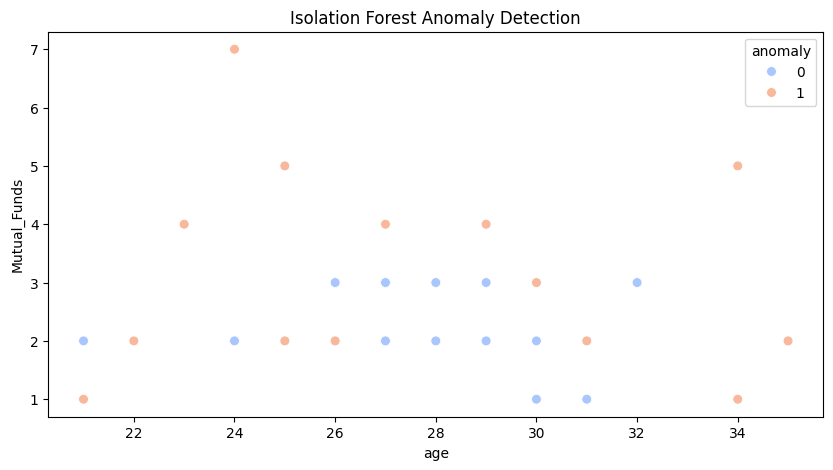

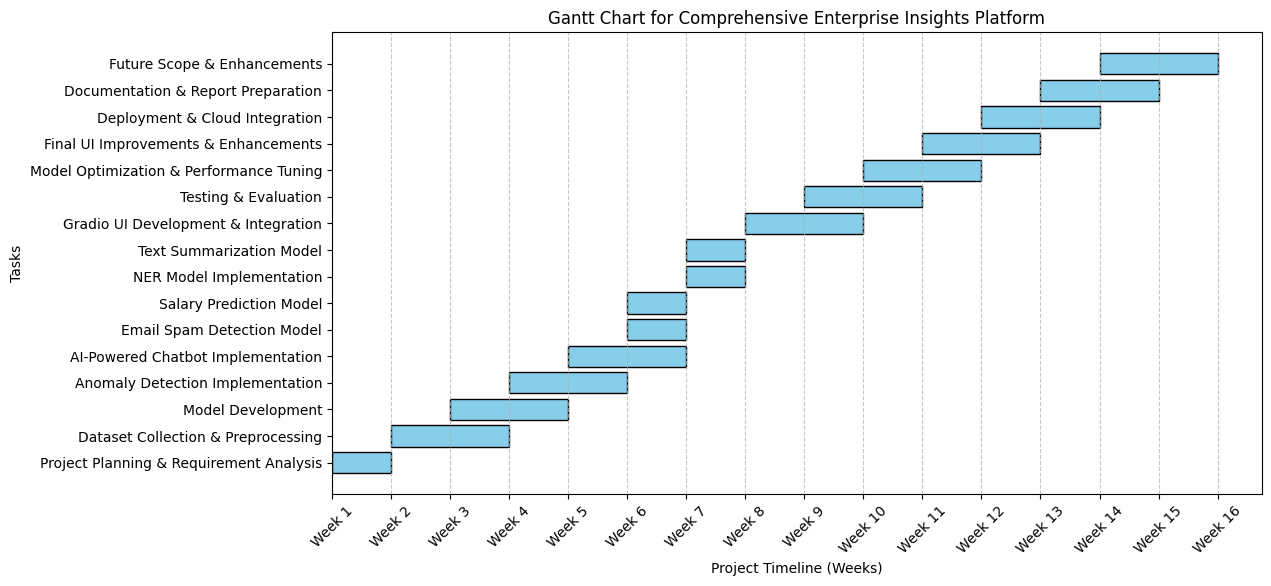

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define tasks and their durations in weeks
tasks = [
    "Project Planning & Requirement Analysis",
    "Dataset Collection & Preprocessing",
    "Model Development",
    "Anomaly Detection Implementation",
    "AI-Powered Chatbot Implementation",
    "Email Spam Detection Model",
    "Salary Prediction Model",
    "NER Model Implementation",
    "Text Summarization Model",
    "Gradio UI Development & Integration",
    "Testing & Evaluation",
    "Model Optimization & Performance Tuning",
    "Final UI Improvements & Enhancements",
    "Deployment & Cloud Integration",
    "Documentation & Report Preparation",
    "Future Scope & Enhancements"
]

# Define start week and duration (in weeks) for each task
start_weeks = np.array([1, 2, 3, 4, 5, 6, 6, 7, 7, 8, 9, 10, 11, 12, 13, 14])
durations = np.array([1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2])

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each task as a horizontal bar
for i, task in enumerate(tasks):
    ax.barh(task, durations[i], left=start_weeks[i], color='skyblue', edgecolor='black')

# Set labels and title
ax.set_xlabel("Project Timeline (Weeks)")
ax.set_ylabel("Tasks")
ax.set_title("Gantt Chart for Comprehensive Enterprise Insights Platform")

# Set x-axis ticks to represent weeks
week_labels = [f"Week {i}" for i in range(1, max(start_weeks + durations) + 1)]
ax.set_xticks(range(1, len(week_labels) + 1))
ax.set_xticklabels(week_labels, rotation=45)

# Show grid
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.show()
